# Import

In [4]:
import os
import numpy as np
from PIL import Image

# Reading Data

In [5]:
!mkdir -p ~/.kaggle
!cp kaggle-2.json ~/.kaggle/

cp: cannot stat 'kaggle-2.json': No such file or directory


In [6]:
! kaggle datasets download -d "ashfakyeafi/cat-dog-images-for-classification"

Dataset URL: https://www.kaggle.com/datasets/ashfakyeafi/cat-dog-images-for-classification
License(s): CC0-1.0
cat-dog-images-for-classification.zip: Skipping, found more recently modified local copy (use --force to force download)


In [7]:

import zipfile
zip_ref = zipfile.ZipFile('/content/cat-dog-images-for-classification.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [8]:
import pandas as pd
df = pd.read_csv("/content/cat_dog.csv")
df

,image,labels
0,dog.11289.jpg,1
1,cat.10836.jpg,0
2,cat.7970.jpg,0
3,cat.2212.jpg,0
4,dog.2653.jpg,1
...,...,...
24995,dog.12201.jpg,1
24996,dog.2893.jpg,1
24997,cat.12267.jpg,0
24998,dog.4380.jpg,1


In [9]:
df.dtypes

,0
image,object
labels,int64


In [10]:
df['image'][0]

'dog.11289.jpg'

# Show an image to check the image type(dog or cat)

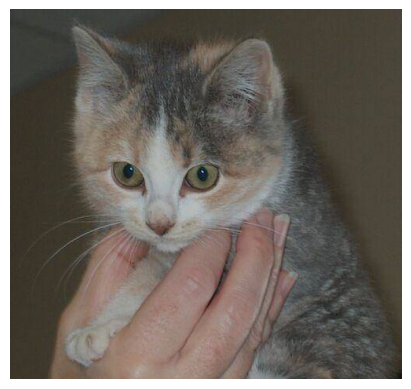

In [11]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Define the path to the image file
image_path = "/content/cat_dog/cat.10002.jpg"

# Load the image
image = mpimg.imread(image_path)

# Display the image
plt.imshow(image)
plt.axis('off')  # Hide axis ticks and labels
plt.show()

# Check image label

In [12]:
# Specify the filename of the image
image_filename = "cat.10002.jpg"

# Filter the DataFrame based on the image filename
image_row = df[df['image'] == image_filename]

# Access the label for the specific image
label = image_row['labels'].iloc[0]

print("Label for", image_filename, ":", label)


Label for cat.10002.jpg : 0


**see that's a cat. image match with its label**

# Count unique values in the 'labels' column

In [13]:
# Count unique values in the 'labels' column
unique_counts = df['labels'].value_counts()

# Display the unique value counts .0 is cat and 1 is cat
unique_counts


,count
labels,
1,12500
0,12500


# Check nan values

**label 1 Dog,
label 0 cat**

In [14]:
# Check for NaN values in the DataFrame
nan_values = df.isna().sum()
nan_values

,0
image,0
labels,0


# Define X,y in dataset


In [15]:
X=df['image']
y=df['labels']
y

,labels
0,1
1,0
2,0
3,0
4,1
...,...
24995,1
24996,1
24997,0
24998,1


# Spliting dataset

In [16]:
from sklearn.model_selection import train_test_split

# Splitting the data into training and testing sets
train_df, test_df = train_test_split(df, test_size=0.3, random_state=0)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# Make train and test images and reshape to 150x150

In [17]:
import imageio

temp_train = []
for img_name in train_df.image:
    img_path = os.path.join("/content/cat_dog", img_name)
    img = imageio.imread(img_path)
    img = np.array(Image.fromarray(img).resize((150, 150))).astype('float32')
    temp_train.append(img)
train_x = np.stack(temp_train)

temp_test = []
for img_name in test_df.image:
    print(img_name)
    img_path = os.path.join("/content/cat_dog", img_name)
    img = imageio.imread(img_path)
    img = np.array(Image.fromarray(img).resize((150, 150))).astype('float32')
    temp_test.append(img)
test_x = np.stack(temp_test)

<ipython-input-17-7bb2683d227d>:6: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(img_path)


cat.5212.jpg
dog.1994.jpg
cat.3255.jpg
cat.6197.jpg
dog.9727.jpg
cat.7265.jpg
dog.4709.jpg
cat.491.jpg
cat.4398.jpg
cat.10234.jpg
dog.2082.jpg
dog.2078.jpg
dog.5192.jpg
dog.873.jpg
cat.7937.jpg
dog.11316.jpg
cat.3477.jpg
cat.9259.jpg
cat.9088.jpg
dog.10605.jpg
cat.4952.jpg
dog.3660.jpg
cat.3090.jpg
dog.3544.jpg
cat.1573.jpg
cat.9704.jpg
cat.9947.jpg
cat.5060.jpg
dog.11332.jpg
dog.10482.jpg
dog.7352.jpg
cat.5041.jpg
dog.7432.jpg
cat.599.jpg
dog.9777.jpg
cat.4526.jpg
cat.1289.jpg
dog.7991.jpg
cat.2621.jpg
dog.2007.jpg
dog.12428.jpg
cat.1118.jpg
dog.4880.jpg
cat.3728.jpg
dog.4185.jpg
dog.4168.jpg
dog.5904.jpg
cat.6928.jpg
cat.10304.jpg
cat.4199.jpg
cat.7384.jpg


<ipython-input-17-7bb2683d227d>:15: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(img_path)


Streaming output truncated to the last 5000 lines.
cat.6235.jpg
cat.1968.jpg
dog.10472.jpg
cat.3245.jpg
cat.6185.jpg
cat.7825.jpg
dog.4866.jpg
cat.4312.jpg
dog.7513.jpg
cat.8130.jpg
dog.8701.jpg
cat.9537.jpg
dog.10070.jpg
cat.6376.jpg
dog.5327.jpg
dog.8474.jpg
dog.7280.jpg
cat.11229.jpg
cat.8445.jpg
dog.6241.jpg
dog.7945.jpg
dog.9066.jpg
dog.1925.jpg
cat.9251.jpg
dog.12354.jpg
dog.4139.jpg
cat.10262.jpg
cat.3285.jpg
cat.8598.jpg
cat.3583.jpg
cat.2753.jpg
cat.6791.jpg
dog.1648.jpg
dog.9466.jpg
cat.1860.jpg
dog.7257.jpg
dog.4235.jpg
cat.3197.jpg
cat.4792.jpg
dog.9522.jpg
cat.955.jpg
dog.786.jpg
cat.8194.jpg
dog.7643.jpg
dog.679.jpg
dog.5837.jpg
dog.11583.jpg
cat.5869.jpg
cat.8924.jpg
dog.1366.jpg
dog.805.jpg
dog.4811.jpg
cat.11964.jpg
dog.5374.jpg
cat.12326.jpg
dog.3575.jpg
cat.11827.jpg
dog.6112.jpg
dog.7186.jpg
cat.11467.jpg
dog.9671.jpg
dog.6421.jpg
cat.3926.jpg
dog.12458.jpg
dog.12212.jpg
dog.8703.jpg
cat.11181.jpg
dog.4322.jpg
cat.7699.jpg
cat.8346.jpg
dog.2020.jpg
dog.2179.jpg
dog.

In [18]:
train_x.shape

(17500, 150, 150, 3)

In [19]:
test_x.shape

(7500, 150, 150, 3)

# Normalizing the test and train images¶


In [20]:
from sklearn.preprocessing import LabelEncoder
import keras

train_x = train_x / 255.
test_x = test_x / 255.

# Encoding the categorical variable to numeric
lb = LabelEncoder()
train_y = lb.fit_transform(train_df.labels)
train_y = keras.utils.to_categorical(train_y)


In [21]:
test_y = lb.fit_transform(test_df.labels)
test_y = keras.utils.to_categorical(test_y)

# Define model

# ANN

In [22]:
from keras.models import Sequential
from keras.layers import Dense, Flatten, InputLayer

# Define the model architecture
model = Sequential()

# Input layer
model.add(InputLayer(input_shape=(150, 150, 3)))

# Flatten the input data
model.add(Flatten())

# Add a fully connected (dense) layer with 128 units and ReLU activation function
model.add(Dense(128, activation='relu'))

# Add the output layer with 2 units and softmax activation function for binary classification
model.add(Dense(2, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Print a summary of the model architecture
model.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_1 (Flatten)         (None, 67500)             0         
                                                                 
 dense_2 (Dense)             (None, 128)               8640128   
                                                                 
 dense_3 (Dense)             (None, 2)                 258       
                                                                 
Total params: 8640386 (32.96 MB)
Trainable params: 8640386 (32.96 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


# Evaluate the mode

In [23]:
# Train the model
history = model.fit(train_x, train_y, epochs=10, batch_size=32, validation_data=(test_x, test_y))


Epoch 1/10
547/547 [==============================] - 191s 347ms/step - loss: 1.4087 - accuracy: 0.5394 - val_loss: 0.6850 - val_accuracy: 0.5841
Epoch 2/10
547/547 [==============================] - 187s 342ms/step - loss: 0.7864 - accuracy: 0.5670 - val_loss: 0.6954 - val_accuracy: 0.5829
Epoch 3/10
547/547 [==============================] - 186s 340ms/step - loss: 0.6983 - accuracy: 0.6006 - val_loss: 0.6792 - val_accuracy: 0.5905
Epoch 4/10
547/547 [==============================] - 187s 342ms/step - loss: 0.6637 - accuracy: 0.6143 - val_loss: 0.7611 - val_accuracy: 0.5303
Epoch 5/10
547/547 [==============================] - 186s 339ms/step - loss: 0.6521 - accuracy: 0.6209 - val_loss: 0.6741 - val_accuracy: 0.5740
Epoch 6/10
547/547 [==============================] - 187s 341ms/step - loss: 0.6474 - accuracy: 0.6214 - val_loss: 0.6516 - val_accuracy: 0.6075
Epoch 7/10
547/547 [==============================] - 186s 340ms/step - loss: 0.6384 - accuracy: 0.6370 - val_loss: 0.6626 -

In [24]:
#!pip install tensorflow==2.13.0

# Evaluate the model

In [25]:
# Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate(test_x, test_y)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

235/235 [==============================] - 5s 21ms/step - loss: 0.6482 - accuracy: 0.6219
Test Loss: 0.6481576561927795
Test Accuracy: 0.6218666434288025


# CNN

In [26]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Define the CNN model architecture
model = Sequential()

# Add the first convolutional layer with 32 filters, each with a 3x3 kernel, and ReLU activation function
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)))

# Add a max pooling layer with a 2x2 pool size
model.add(MaxPooling2D(pool_size=(2, 2)))

# Add a second convolutional layer with 64 filters, each with a 3x3 kernel, and ReLU activation function
model.add(Conv2D(64, (3, 3), activation='relu'))

# Add another max pooling layer
model.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten the output from the convolutional layers to feed into the dense layers (ANN)
model.add(Flatten())

# Add a fully connected (dense) layer with 128 units and ReLU activation function
model.add(Dense(128, activation='relu'))

# Add the output layer with 2 units and softmax activation function for binary classification
model.add(Dense(2, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Print a summary of the model architecture
model.summary()


Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 148, 148, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 74, 74, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 72, 72, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 36, 36, 64)        0         
 g2D)                                                            
                                                                 
 flatten_2 (Flatten)         (None, 82944)             0         
                                                                 
 dense_4 (Dense)             (None, 128)              

# Train the model

In [ ]:
# Train the model
history = model.fit(train_x, train_y, epochs=10, batch_size=32, validation_data=(test_x, test_y))


Epoch 1/10
547/547 [==============================] - 652s 1s/step - loss: 0.6490 - accuracy: 0.6365 - val_loss: 0.5972 - val_accuracy: 0.6935
Epoch 2/10
547/547 [==============================] - 644s 1s/step - loss: 0.5172 - accuracy: 0.7458 - val_loss: 0.5517 - val_accuracy: 0.7260
Epoch 3/10
547/547 [==============================] - 646s 1s/step - loss: 0.3921 - accuracy: 0.8197 - val_loss: 0.5325 - val_accuracy: 0.7491
Epoch 4/10
547/547 [==============================] - 649s 1s/step - loss: 0.2299 - accuracy: 0.9085 - val_loss: 0.6533 - val_accuracy: 0.7432
Epoch 5/10
547/547 [==============================] - 652s 1s/step - loss: 0.0910 - accuracy: 0.9702 - val_loss: 1.0192 - val_accuracy: 0.7467
Epoch 6/10
547/547 [==============================] - 649s 1s/step - loss: 0.0346 - accuracy: 0.9899 - val_loss: 1.1658 - val_accuracy: 0.7452
Epoch 7/10
547/547 [==============================] - 656s 1s/step - loss: 0.0346 - accuracy: 0.9905 - val_loss: 1.1543 - val_accuracy: 0.7467

# Evaluate the model

In [1]:
# Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate(test_x, test_y)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


NameError: name 'model' is not defined

# We faced overfitting

Strategies to reduce overfitting:

1. **Increase Training Data**: More data helps the model generalize better.
2. **Data Augmentation**: Apply transformations to increase dataset diversity.
3. **Regularization**: Use techniques like dropout and L2 regularization.
4. **Simplify Model**: Reduce complexity by removing layers or units.
5. **Early Stopping**: Stop training when validation performance degrades.
6. **Batch Normalization**: Stabilize training by normalizing layer activations.
7. **Transfer Learning**: Fine-tune pre-trained models for your task.
8. **Cross-Validation**: Assess model generalization using k-fold cross-validation.

**I choose Dropout**


In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Define the CNN model architecture
model = Sequential()

# Add the first convolutional layer with 32 filters, each with a 3x3 kernel, and ReLU activation function
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)))

# Add a max pooling layer with a 2x2 pool size
model.add(MaxPooling2D(pool_size=(2, 2)))

# Add dropout after the first max pooling layer
#model.add(Dropout(0.1))

# Add a second convolutional layer with 64 filters, each with a 3x3 kernel, and ReLU activation function
model.add(Conv2D(64, (3, 3), activation='relu'))

# Add another max pooling layer
model.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten the output from the convolutional layers to feed into the dense layers (ANN)
model.add(Flatten())

# Add dropout before the fully connected layer
model.add(Dropout(0.1))

# Add a fully connected (dense) layer with 128 units and ReLU activation function
model.add(Dense(128, activation='relu'))

# Add dropout before the output layer
model.add(Dropout(0.1))

# Add the output layer with 2 units and softmax activation function for binary classification
model.add(Dense(2, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Print a summary of the model architecture
model.summary()


In [ ]:
# Train the model
# Fit the model to the training data
history = model.fit(train_x, train_y, epochs=10, batch_size=32, validation_data=(test_x, test_y))


In [ ]:
# Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate(test_x, test_y)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

**Data augmentation is a technique used to increase the diversity of a dataset by applying various transformations to the existing images**

In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom

# Define data augmentation pipeline
data_augmentation = Sequential([
    RandomFlip("horizontal", input_shape=(150, 150, 3)),
    RandomRotation(0.2),
    RandomZoom(0.2),
])

# Define the CNN model architecture
model = Sequential()

# Apply data augmentation to the input data
model.add(data_augmentation)

# Add the first convolutional layer with 32 filters, each with a 3x3 kernel, and ReLU activation function
model.add(Conv2D(32, (3, 3), activation='relu'))

# Add a max pooling layer with a 2x2 pool size
model.add(MaxPooling2D(pool_size=(2, 2)))

# Add a second convolutional layer with 64 filters, each with a 3x3 kernel, and ReLU activation function
model.add(Conv2D(64, (3, 3), activation='relu'))

# Add another max pooling layer
model.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten the output from the convolutional layers to feed into the dense layers (ANN)
model.add(Flatten())

# Add dropout before the fully connected layer
model.add(Dropout(0.1))

# Add a fully connected (dense) layer with 128 units and ReLU activation function
model.add(Dense(128, activation='relu'))

# Add dropout before the output layer
model.add(Dropout(0.1))

# Add the output layer with 2 units and softmax activation function for binary classification
model.add(Dense(2, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Print a summary of the model architecture
model.summary()


In [ ]:
# Train the model
# Fit the model to the training data
history = model.fit(train_x, train_y, epochs=10, batch_size=16, validation_data=(test_x, test_y))


In [ ]:
test_loss, test_accuracy = model.evaluate(test_x, test_y)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


#method 02# by using reset